<a href="https://colab.research.google.com/github/mickael044/CodeAlpha_DiseasePrediction/blob/main/CodeAlpha_DiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CodeAlpha Internship: Disease Prediction from Medical Data

**Objective:** Predict whether a breast tumor is malignant or benign from patient diagnostic measurements, using and comparing four classification algorithms (Logistic Regression, Random Forest, SVM, XGBoost).

**Dataset:** Breast Cancer Wisconsin (Diagnostic), 569 samples, 30 numeric features.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# install data
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target   # 0 = (malignant), 1 = (benign)

print("Measure:", df.shape)
df.head()

Measure: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

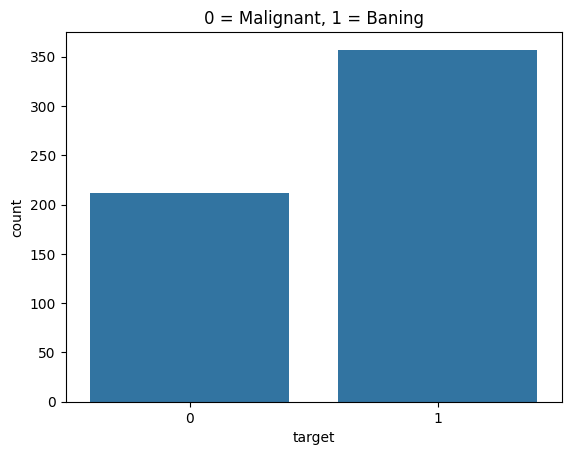

In [10]:
# 1. general information
df.info()

# 2. there is empty information?
print("Null information:", df.isnull().sum().sum())

# 3. Statistiks
df.describe().T.head(10)

# 4. target: how many malignant how many bening
print(df["target"].value_counts())
sns.countplot(x="target", data=df)
plt.title("0 = Malignant, 1 = Baning")
plt.show()

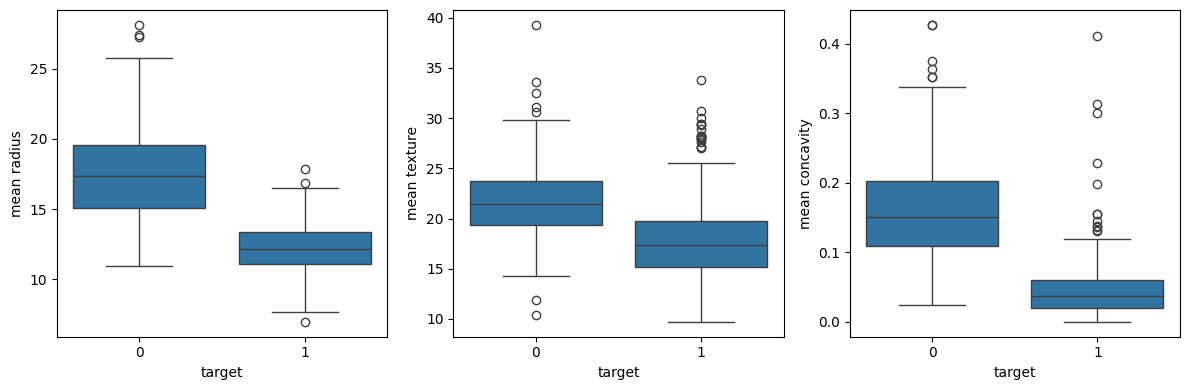

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [11]:
# 5. the most important feature
plt.figure(figsize=(12, 4))
for i, col in enumerate(["mean radius", "mean texture", "mean concavity"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x="target", y=col, data=df)
plt.tight_layout()
plt.show()

# 6. korrelation
corr = df.corr()["target"].abs().sort_values(ascending=False)[1:11]
print(corr)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. X (feature) və y (target) ayır
X = df.drop("target", axis=1)
y = df["target"]

# 2. Train/test: 80% teach, 20% try
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn only in trin
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    # Logistic Regression and SVM üçün scaled data
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    trained[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.982,0.986,0.986,0.986,0.995
Random Forest,0.956,0.959,0.972,0.966,0.993
SVM,0.982,0.986,0.986,0.986,0.995
XGBoost,0.956,0.947,0.986,0.966,0.993


Choose the best model: Logistic Regression


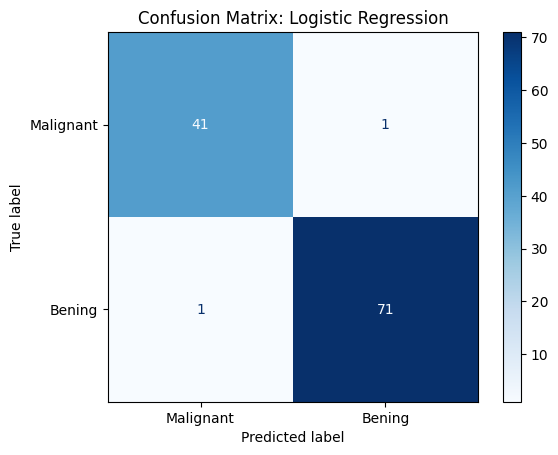

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Bening       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



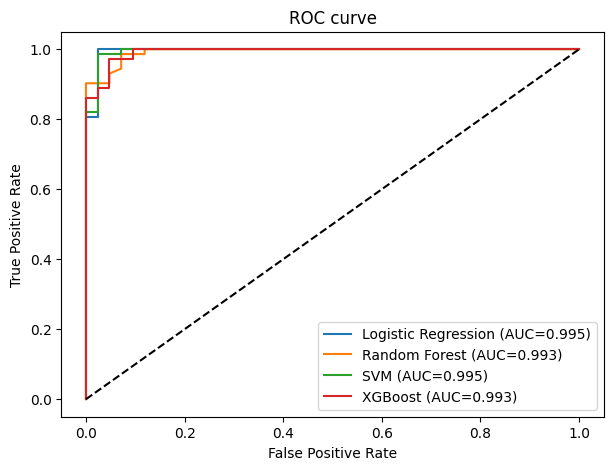

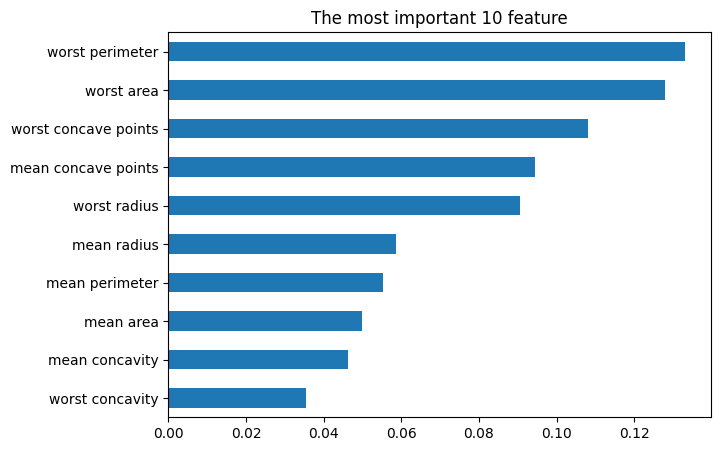

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve

# 1. choose the best model for F1
best_name = results_df["F1"].idxmax()
best_model = trained[best_name]
print("Choose the best model:", best_name)

y_pred = best_model.predict(X_test_scaled)

# 2. Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Malignant", "Bening"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

# 3. detailed report
print(classification_report(y_test, y_pred, target_names=["Malignant", "Bening"]))

# 4. ROC for every model
plt.figure(figsize=(7, 5))
for name, model in trained.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results_df.loc[name, 'ROC-AUC']})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

# 5. the besrt 10 feture for Random Forest
rf = trained["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
importances.sort_values().plot(kind="barh", figsize=(7, 5), title="The most important 10 feature")
plt.show()

## Conclusion

- **Best model:** Logistic Regression (tied with SVM), with an F1-score of 0.986 and ROC-AUC of 0.995 on the test set.
- All four models performed strongly, with ROC-AUC between 0.993 and 0.995, so the dataset is well separable.
- **Most important features:** worst perimeter, worst area and worst concave points. Tumor size and irregular shape are the strongest indicators of malignancy.
- **Medical note:** In this problem the costliest error is a false negative (a malignant tumor predicted as benign). For that reason, recall on the malignant class was examined alongside overall accuracy.
- **Possible improvements:** hyperparameter tuning (GridSearchCV), cross-validation, and testing on other datasets such as Heart Disease or Diabetes.